In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/juhibhojani/house-price/house_prices.csv


In [2]:
from matplotlib import pyplot as plt
import pandas as pd

In [3]:
house_price=pd.read_csv("/kaggle/input/datasets/juhibhojani/house-price/house_prices.csv")

In [4]:
house_price.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [5]:
house_price.shape

(187531, 21)

In [6]:
house_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [7]:
Price=house_price['Price (in rupees)']

In [8]:
p=Price.dropna()
p

0          6000.0
1         13799.0
2         17500.0
4         18824.0
5          6618.0
           ...   
187526     3225.0
187527     3274.0
187528     4343.0
187529     4231.0
187530     6162.0
Name: Price (in rupees), Length: 169866, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x79ff3aca7e60>,
 'caps': [<matplotlib.lines.Line2D at 0x79ff3acc4500>,
 'boxes': [<matplotlib.lines.Line2D at 0x79ff3aca73e0>],
 'medians': [<matplotlib.lines.Line2D at 0x79ff3acc4a10>],
 'fliers': [<matplotlib.lines.Line2D at 0x79ff3acc4d10>],
 'means': []}

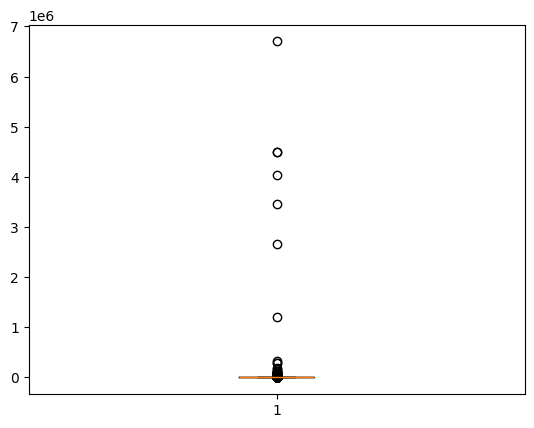

In [9]:
plt.boxplot(p)

In [10]:
Q1=p.quantile(0.25)
Q2=p.quantile(0.5)
Q3=p.quantile(0.75)
Q1,Q2,Q3

(np.float64(4297.0), np.float64(6034.0), np.float64(9450.0))

In [11]:
IQR=Q3-Q1
IQR

np.float64(5153.0)

In [12]:
up=Q3+1.5*IQR
ll=Q1-1.5*IQR
up,ll

(np.float64(17179.5), np.float64(-3432.5))

In [13]:
Outliers=Price[(Price < ll) | (Price > up)]
Outliers

2          17500.0
4          18824.0
13         17526.0
30         17827.0
64         18750.0
            ...   
181990     26718.0
183303     40000.0
183490    291667.0
185135     60000.0
185958     25000.0
Name: Price (in rupees), Length: 7932, dtype: float64

In [14]:
num_outliers = len(Outliers)
total = len(Price)
outlier_percentage = (num_outliers / total) * 100
print(outlier_percentage)

4.229700689486005
